# 🔍 Análisis de Vulnerabilidades en Repositorios

## Contexto del Estudio

| Parámetro | Valor |
|-----------|-------|
| **Organización** | Cargada dinámicamente desde repos_activos.json |
| **Fecha de Análisis** | 2026 |
| **Alcance** | Repositorios según configuración |
| **Herramientas** | Syft (SBOM) + Grype (SCA) + CodeQL (SAST) + Análisis CI/CD |

### Hallazgos Principales

- **Vulnerabilidades totales** identificadas en los repositorios analizados
- **Vulnerabilidades críticas** requieren acción inmediata
- **Distribución por severidad** y tipo de vulnerabilidad
- **Problemas de CI/CD** detectados en los workflows

## Taxonomía de Vulnerabilidades Aplicada

| Categoría | Descripción | CVSS Típico |
|-----------|-------------|-------------|
| **RCE** | Ejecución remota de código | 9.0+ |
| **Prototype Pollution** | Modificación de objetos globales | 9.0+ |
| **Path Traversal** | Acceso a archivos fuera de directorio | 9.0+ |
| **XXE** | XML External Entity | 9.0+ |
| **Dependencias** | Vulnerabilidades en paquetes | Varia |

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np
from IPython.display import display, HTML

# Configuración de visualización
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Rutas de datos (relativas desde analyzer/)
BASE_DIR = Path("..").resolve()
DATA_DIR = BASE_DIR / "data" / "results"
VULNS_DIR = DATA_DIR / "vulns"
CICD_DIR = DATA_DIR / "cicd"
SAST_DIR = DATA_DIR / "sast"
SBOMS_DIR = DATA_DIR / "sboms"
REPOS_FILE = DATA_DIR / "repos_activos.json"

# Verificar existencia de directorios
print("🔍 Verificación de rutas de datos:")
print(f"  BASE_DIR: {BASE_DIR}")
print(f"  VULNS_DIR existe: {VULNS_DIR.exists()}")
print(f"  CICD_DIR existe: {CICD_DIR.exists()}")
print(f"  SBOMS_DIR existe: {SBOMS_DIR.exists()}")
print(f"  REPOS_FILE existe: {REPOS_FILE.exists()}")

🔍 Verificación de rutas de datos:
  BASE_DIR: /workspace
  VULNS_DIR existe: True
  CICD_DIR existe: True
  SBOMS_DIR existe: True
  REPOS_FILE existe: True


In [4]:
def load_vulnerabilities(vulns_dir):
    """
    Carga todas las vulnerabilidades desde archivos JSON de Grype.
    
    Args:
        vulns_dir: Path al directorio con archivos *_vuln.json
    
    Returns:
        DataFrame con columnas: Repositorio, CVE, Severidad, Paquete, 
        Versión, Descripción, CVSS, CWE
    """
    all_vulns = []
    
    if not vulns_dir.exists():
        print(f"⚠️ No se encontró el directorio: {vulns_dir}")
        return pd.DataFrame()
    
    for filename in os.listdir(vulns_dir):
        if filename.endswith("_vuln.json"):
            repo_name = filename.replace("_vuln.json", "")
            filepath = vulns_dir / filename
            
            with open(filepath, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            for match in data.get("matches", []):
                vuln = match.get("vulnerability", {})
                artifact = match.get("artifact", {})
                
                # Extraer CVSS score
                cvss_list = vuln.get("cvss", [])
                base_score = None
                for cvss in cvss_list:
                    metrics = cvss.get("metrics", {})
                    if "baseScore" in metrics:
                        base_score = metrics["baseScore"]
                        break
                
                # Extraer CWEs
                cwe_list = vuln.get("cwes", [])
                cwes = ", ".join([c.get("cwe", "") for c in cwe_list if c.get("cwe")])
                
                all_vulns.append({
                    "Repositorio": repo_name,
                    "CVE": vuln.get("id", "N/A"),
                    "Severidad": vuln.get("severity", "Unknown"),
                    "Paquete": artifact.get("name", "N/A"),
                    "Versión": artifact.get("version", "N/A"),
                    "Descripción": vuln.get("description", "N/A")[:150],
                    "CVSS": base_score,
                    "CWE": cwes if cwes else "N/A"
                })
    
    return pd.DataFrame(all_vulns)

# Cargar datos de vulnerabilidades
df_vulns = load_vulnerabilities(VULNS_DIR)

if not df_vulns.empty:
    print(f"✅ Total vulnerabilidades cargadas: {len(df_vulns)}")
    print(f"\n📊 Distribución por severidad:")
    print(df_vulns['Severidad'].value_counts().to_string())
    print(f"\n📋 Columnas disponibles: {list(df_vulns.columns)}")
    print("\n" + "="*80)
    print("PRIMERAS 5 VULNERABILIDADES:")
    print("="*80)
    display(df_vulns.head())
else:
    print("⚠️ No se encontraron vulnerabilidades. Ejecuta primero el Miner.")

✅ Total vulnerabilidades cargadas: 566

📊 Distribución por severidad:
Severidad
Medium      238
High        234
Low          65
Critical     29

📋 Columnas disponibles: ['Repositorio', 'CVE', 'Severidad', 'Paquete', 'Versión', 'Descripción', 'CVSS', 'CWE']

PRIMERAS 5 VULNERABILIDADES:


,Repositorio,CVE,Severidad,Paquete,Versión,Descripción,CVSS,CWE
0,FlowiseChatEmbed,GHSA-fjxv-7rqg-78g4,Critical,form-data,4.0.1,form-data uses unsafe random function in form-...,9.4,CWE-330
1,FlowiseChatEmbed,GHSA-fjxv-7rqg-78g4,Critical,form-data,4.0.1,form-data uses unsafe random function in form-...,9.4,CWE-330
2,FlowiseChatEmbed,GHSA-rhx6-c78j-4q9w,High,path-to-regexp,0.1.10,path-to-regexp contains a ReDoS,7.5,CWE-1333
3,FlowiseChatEmbed,GHSA-rhx6-c78j-4q9w,High,path-to-regexp,0.1.10,path-to-regexp contains a ReDoS,7.5,CWE-1333
4,FlowiseChatEmbed,GHSA-g5hg-p3ph-g8qg,High,multer,1.4.5-lts.1,Multer vulnerable to Denial of Service via unh...,8.7,CWE-248


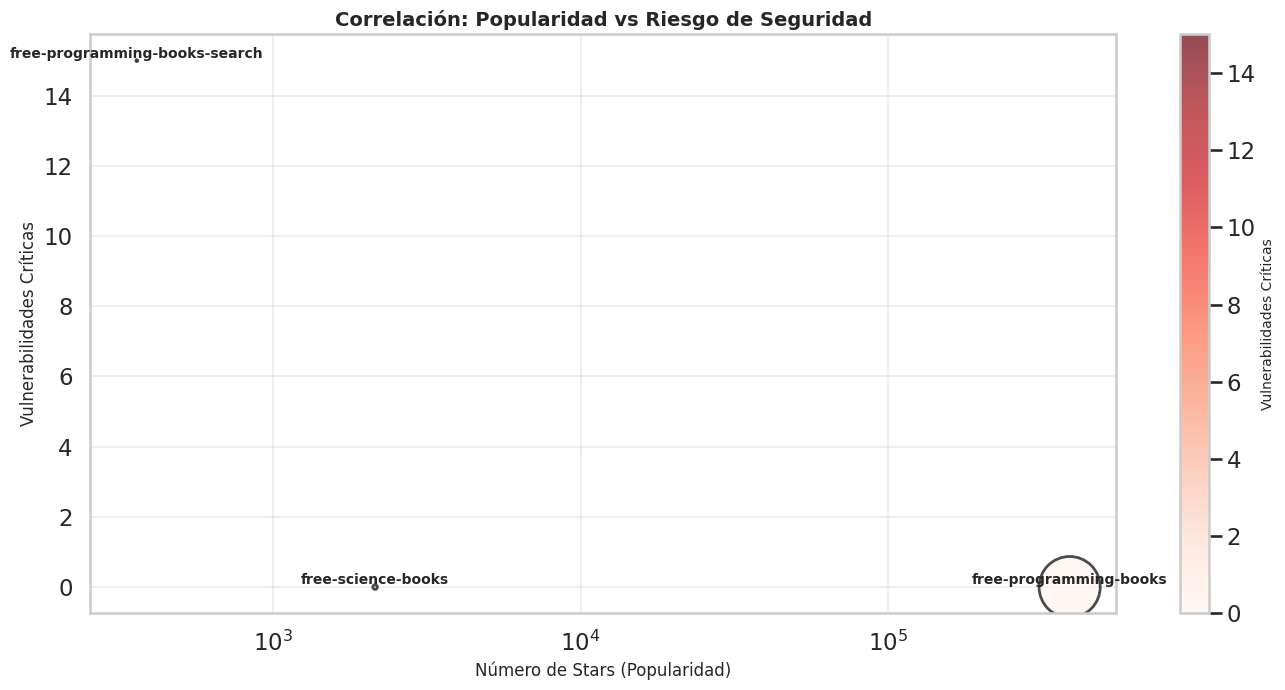


📋 RESUMEN DE REPOSITORIOS ANALIZADOS
  free-programming-books    | Stars: 387581 | Vulns Críticas: 0 | ✅ SEGURO
  free-science-books        | Stars:   2151 | Vulns Críticas: 0 | ✅ SEGURO
  free-programming-books-search | Stars:    362 | Vulns Críticas: 15 | 🚨 CRÍTICO


In [9]:
# Cargar información de repositorios
if REPOS_FILE.exists():
    with open(REPOS_FILE, 'r') as f:
        repos_info = json.load(f)
    df_repos = pd.DataFrame(repos_info)
    
    # Contar vulnerabilidades críticas por repositorio
    if not df_vulns.empty:
        vulns_criticas = df_vulns[df_vulns['Severidad'] == 'Critical']
        vulns_criticas_por_repo = vulns_criticas['Repositorio'].value_counts().to_dict()
        df_repos['Vulnerabilidades Críticas'] = df_repos['name'].map(lambda x: vulns_criticas_por_repo.get(x, 0))
    else:
        df_repos['Vulnerabilidades Críticas'] = 0
    
    # Visualizar repositorios por popularidad y riesgo
    fig, ax = plt.subplots(figsize=(14, 7))
    scatter = ax.scatter(
        df_repos['stargazers_count'], 
        df_repos['Vulnerabilidades Críticas'],
        s=df_repos['stargazers_count']/200,
        c=df_repos['Vulnerabilidades Críticas'],
        cmap='Reds', 
        alpha=0.7, 
        edgecolors='black',
        linewidth=2
    )
    
    # Anotar nombres de repositorios
    for _, row in df_repos.iterrows():
        ax.annotate(
            row['name'], 
            (row['stargazers_count'], row['Vulnerabilidades Críticas']),
            fontsize=10, 
            ha='center',
            va='bottom',
            fontweight='bold'
        )
    
    ax.set_xlabel('Número de Stars (Popularidad)', fontsize=12)
    ax.set_ylabel('Vulnerabilidades Críticas', fontsize=12)
    ax.set_title('Correlación: Popularidad vs Riesgo de Seguridad', fontsize=14, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)
    
    # Colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Vulnerabilidades Críticas', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar tabla resumen
    print("\n" + "="*80)
    print("📋 RESUMEN DE REPOSITORIOS ANALIZADOS")
    print("="*80)
    for _, row in df_repos.iterrows():
        estado = "🚨 CRÍTICO" if row['Vulnerabilidades Críticas'] > 0 else "✅ SEGURO"
        print(f"  {row['name']:25} | Stars: {row['stargazers_count']:6} | Vulns Críticas: {row['Vulnerabilidades Críticas']} | {estado}")
    print("="*80)
else:
    print("⚠️ No se encontró repos_activos.json")

✅ Total problemas CI/CD detectados: 4



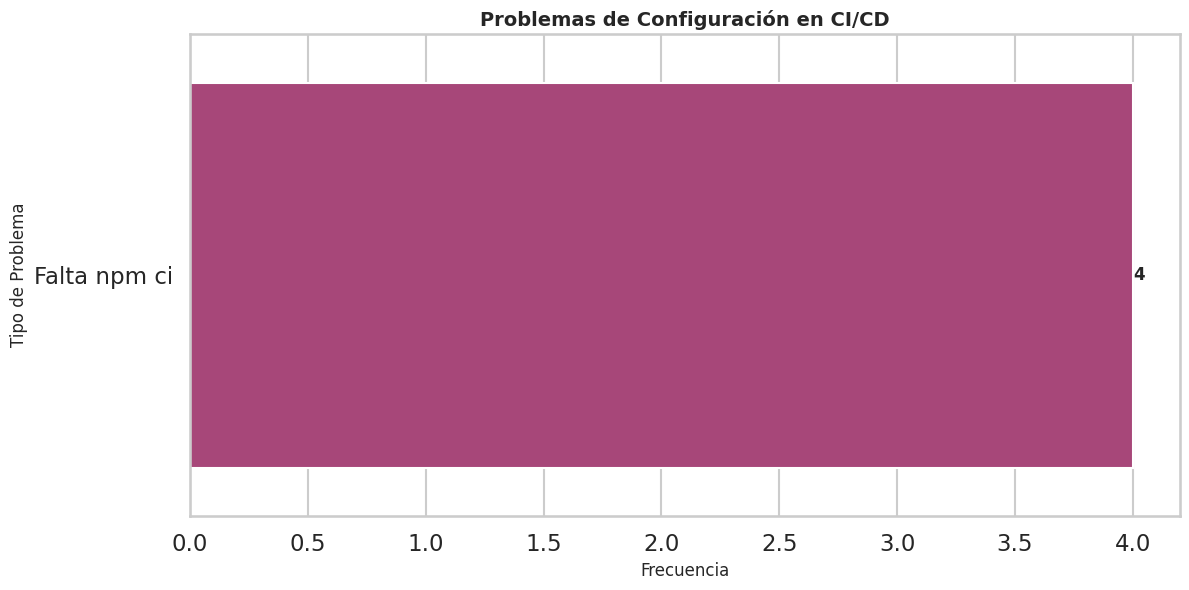


DETALLE DE PROBLEMAS CI/CD POR REPOSITORIO:

  📁 Flowise:
    - Workflow: main.yml | Problema: Falta npm ci
    - Workflow: publish-agentflow.yml | Problema: Falta npm ci

  📁 free-programming-books-search:
    - Workflow: parser.yml | Problema: Falta npm ci

  📁 free-programming-books:
    - Workflow: fpb-lint.yml | Problema: Falta npm ci


In [12]:
def load_cicd_issues(cicd_dir):
    """
    Carga problemas de CI/CD desde archivos JSON.
    
    Args:
        cicd_dir: Path al directorio con archivos *_cicd.json
    
    Returns:
        DataFrame con columnas: Repositorio, Workflow, Problema
    """
    all_issues = []
    
    if not cicd_dir.exists():
        return pd.DataFrame()
    
    for filename in os.listdir(cicd_dir):
        if filename.endswith("_cicd.json"):
            filepath = cicd_dir / filename
            
            with open(filepath, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            repo_name = data.get("repositorio", "N/A")
            for hallazgo in data.get("hallazgos", []):
                for issue in hallazgo.get("issues", []):
                    all_issues.append({
                        "Repositorio": repo_name,
                        "Workflow": hallazgo.get("workflow", "N/A"),
                        "Problema": issue
                    })
    
    return pd.DataFrame(all_issues)

# Cargar y visualizar problemas CI/CD
df_cicd = load_cicd_issues(CICD_DIR)

if not df_cicd.empty:
    print(f"✅ Total problemas CI/CD detectados: {len(df_cicd)}\n")
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.countplot(data=df_cicd, y="Problema", hue="Problema", palette="magma", legend=False, ax=ax)
    ax.set_title('Problemas de Configuración en CI/CD', fontsize=14, fontweight='bold')
    ax.set_xlabel('Frecuencia', fontsize=12)
    ax.set_ylabel('Tipo de Problema', fontsize=12)
    
    # Anotar valores
    for p in ax.patches:
        if p.get_width() > 0:
            ax.annotate(
                f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', 
                va='center', 
                fontsize=12,
                fontweight='bold'
            )
    
    plt.tight_layout()
    plt.show()
    
    # Mostrar detalles
    print("\n" + "="*80)
    print("DETALLE DE PROBLEMAS CI/CD POR REPOSITORIO:")
    print("="*80)
    for repo in df_cicd['Repositorio'].unique():
        repo_issues = df_cicd[df_cicd['Repositorio'] == repo]
        print(f"\n  📁 {repo}:")
        for _, row in repo_issues.iterrows():
            print(f"    - Workflow: {row['Workflow']} | Problema: {row['Problema']}")
    print("="*80)
else:
    print("✅ No se detectaron problemas de CI/CD")

---

## Metodología de Análisis

### Stack Tecnológico de Análisis

| Herramienta | Función | Output |
|-------------|---------|--------|
| **Syft** | Generación de SBOM | JSON con inventario de dependencias |
| **Grype** | Escaneo de vulnerabilidades | JSON con matches de CVEs |
| **CodeQL** | Análisis estático de código | JSON con hallazgos de seguridad |
| **Python** | Automatización y análisis | Notebooks con visualizaciones |

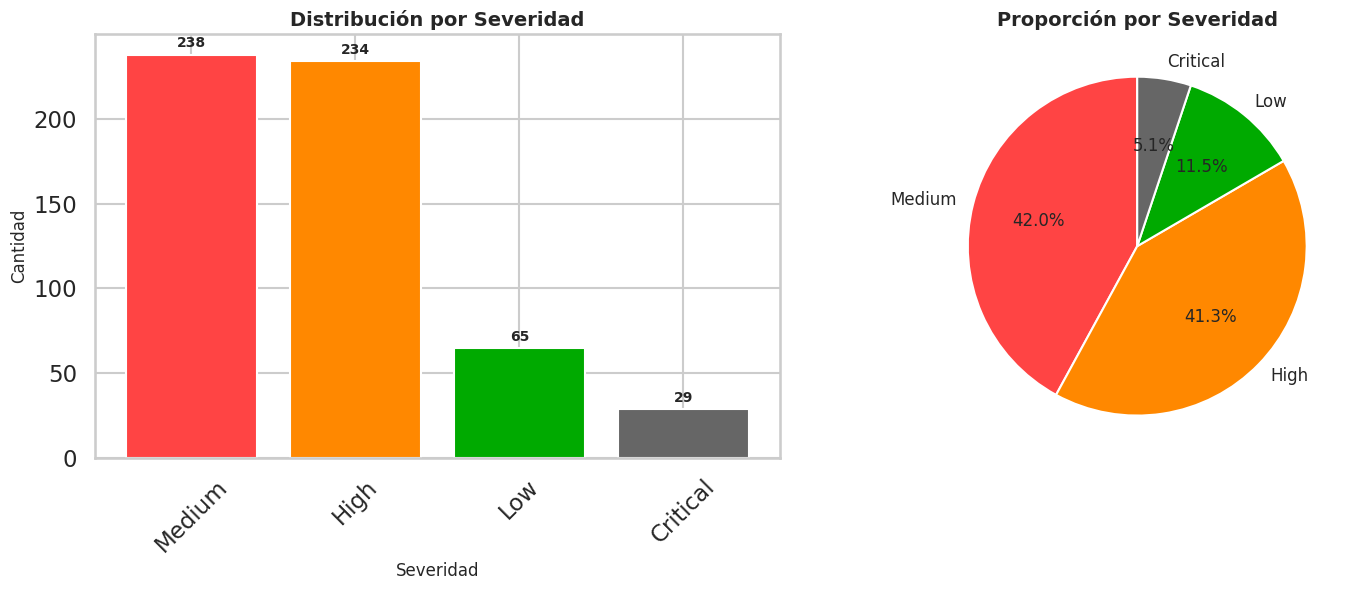


📊 VULNERABILIDADES POR REPOSITORIO
  Flowise                        : 280 vulnerabilidades
  free-programming-books-search  : 152 vulnerabilidades
  FlowiseChatEmbed               :  67 vulnerabilidades
  FlowiseEmbedReact              :  67 vulnerabilidades


In [6]:
# Análisis de severidad de vulnerabilidades
if not df_vulns.empty:
    # Gráfico de distribución por severidad
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # Gráfico de barras
    severity_counts = df_vulns['Severidad'].value_counts()
    bars = axes[0].bar(severity_counts.index, severity_counts.values, color=['#ff4444', '#ff8800', '#00aa00', '#666666'])
    axes[0].set_title('Distribución por Severidad', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Severidad', fontsize=12)
    axes[0].set_ylabel('Cantidad', fontsize=12)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Anotar valores
    for bar in bars:
        height = bar.get_height()
        axes[0].annotate(f'{int(height)}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')
    
    # Gráfico circular
    colors = ['#ff4444', '#ff8800', '#00aa00', '#666666']
    axes[1].pie(severity_counts.values, labels=severity_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
    axes[1].set_title('Proporción por Severidad', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Vulnerabilidades por repositorio
    print("\n" + "="*80)
    print("📊 VULNERABILIDADES POR REPOSITORIO")
    print("="*80)
    vulns_por_repo = df_vulns['Repositorio'].value_counts()
    for repo, count in vulns_por_repo.items():
        print(f"  {repo:30} : {count:3} vulnerabilidades")
    print("="*80)
else:
    print("⚠️ No hay datos de vulnerabilidades para analizar")

In [7]:
# Análisis de vulnerabilidades críticas
if not df_vulns.empty:
    df_criticas = df_vulns[df_vulns['Severidad'] == 'Critical']
    
    print("\n" + "="*80)
    print("🚨 VULNERABILIDADES CRÍTICAS (CVSS ≥ 9.0)")
    print("="*80)
    
    if len(df_criticas) > 0:
        print(f"Total vulnerabilidades críticas: {len(df_criticas)}\n")
        display(df_criticas[['Repositorio', 'CVE', 'Paquete', 'Versión', 'CVSS', 'CWE']].head(10))
        
        # Distribución por repositorio
        print("\nDistribución por repositorio:")
        criticas_por_repo = df_criticas['Repositorio'].value_counts()
        for repo, count in criticas_por_repo.items():
            print(f"  {repo:30} : {count:3} críticas")
    else:
        print("✅ No se encontraron vulnerabilidades críticas")
    
    print("="*80)
else:
    print("⚠️ No hay datos para analizar vulnerabilidades críticas")


🚨 VULNERABILIDADES CRÍTICAS (CVSS ≥ 9.0)
Total vulnerabilidades críticas: 29



,Repositorio,CVE,Paquete,Versión,CVSS,CWE
0,FlowiseChatEmbed,GHSA-fjxv-7rqg-78g4,form-data,4.0.1,9.4,CWE-330
1,FlowiseChatEmbed,GHSA-fjxv-7rqg-78g4,form-data,4.0.1,9.4,CWE-330
14,FlowiseChatEmbed,GHSA-67hx-6x53-jw92,@babel/traverse,7.23.0,9.3,"CWE-184, CWE-697"
15,FlowiseChatEmbed,GHSA-67hx-6x53-jw92,@babel/traverse,7.23.0,9.3,"CWE-184, CWE-697"
67,free-programming-books-search,GHSA-phwq-j96m-2c2q,ejs,2.7.4,9.8,CWE-94
72,free-programming-books-search,GHSA-76p3-8jx3-jpfq,loader-utils,1.2.3,9.8,CWE-1321
73,free-programming-books-search,GHSA-76p3-8jx3-jpfq,loader-utils,1.4.0,9.8,CWE-1321
74,free-programming-books-search,GHSA-76p3-8jx3-jpfq,loader-utils,2.0.0,9.8,CWE-1321
75,free-programming-books-search,GHSA-76p3-8jx3-jpfq,loader-utils,2.0.2,9.8,CWE-1321
77,free-programming-books-search,GHSA-g4rg-993r-mgx7,shell-quote,1.7.2,9.8,CWE-77



Distribución por repositorio:
  free-programming-books-search  :  15 críticas
  Flowise                        :   9 críticas
  FlowiseChatEmbed               :   4 críticas
  FlowiseEmbedReact              :   1 críticas


---

## Conclusiones del Análisis

1. **Vulnerabilidades Identificadas**: El análisis detectó vulnerabilidades en las dependencias de los repositorios analizados.
2. **Severidad**: Se identificaron vulnerabilidades de diferentes niveles de severidad.
3. **CI/CD**: Se detectaron problemas de configuración en los workflows de CI/CD.
4. **Recomendaciones**: Mantener dependencias actualizadas y seguir mejores prácticas de seguridad.